# PERTEMUAN 10 — ALGORITMA KLASIFIKASI (BAGIAN 2)

**Nama:** Suryani Tangdiaga  
**NIM:** 250401020097  
**Kelas:** IF405  
**Program Studi:** Informatika  

## Materi
- Imbalanced Classification
- Random Forest
- Encoding Data Kategorikal
- Stratified Train-Test Split
- Precision, Recall, F1-Score
- ROC-AUC
- Prediksi Probabilitas Churn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

print("Library berhasil dimuat.")

Library berhasil dimuat.


In [2]:
df = pd.read_csv("telco_churn.csv")

print("Ukuran dataset:", df.shape)

print("\n5 data pertama:")
display(df.head())

print("\nTipe data:")
print(df.dtypes)

print("\nDistribusi Churn:")
print(df["Churn"].value_counts())

print("\nProporsi Churn:")
print(df["Churn"].value_counts(normalize=True).round(3))

Ukuran dataset: (7043, 21)

5 data pertama:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Tipe data:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Distribusi Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proporsi Churn:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


In [3]:
# Salin dataset agar data asli tetap aman
data = df.copy()

# Hapus kolom ID pelanggan jika tersedia
if "customerID" in data.columns:
    data = data.drop(columns=["customerID"])

# Ubah target Churn menjadi angka
data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Pisahkan fitur dan target
X = data.drop(columns=["Churn"])
y = data["Churn"]

# Encoding fitur kategorikal
X = pd.get_dummies(X, drop_first=True)

# Pastikan semua fitur berupa numerik
X = X.astype(float)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

print("\nTarget:")
print(y.value_counts())

Shape X: (7043, 6559)
Shape y: (7043,)

Target:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [4]:
print("Jumlah missing value:")
print(X.isnull().sum().sort_values(ascending=False).head(10))

Jumlah missing value:
SeniorCitizen                     0
tenure                            0
MonthlyCharges                    0
gender_Male                       0
Partner_Yes                       0
Dependents_Yes                    0
PhoneService_Yes                  0
MultipleLines_No phone service    0
MultipleLines_Yes                 0
InternetService_Fiber optic       0
dtype: int64


In [5]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Data training :", X_tr.shape)
print("Data testing  :", X_te.shape)

print("\nDistribusi target training:")
print(y_tr.value_counts(normalize=True).round(3))

print("\nDistribusi target testing:")
print(y_te.value_counts(normalize=True).round(3))

Data training : (5634, 6559)
Data testing  : (1409, 6559)

Distribusi target training:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Distribusi target testing:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [6]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_tr, y_tr)

print("Random Forest berhasil dilatih.")

Random Forest berhasil dilatih.


In [7]:
y_pred = rf.predict(X_te)

y_proba = rf.predict_proba(X_te)[:, 1]

print("Prediksi berhasil.")
print("Jumlah data testing:", len(y_pred))

Prediksi berhasil.
Jumlah data testing: 1409


In [8]:
print("=== HASIL EVALUASI RANDOM FOREST ===\n")

print("Accuracy :", round(accuracy_score(y_te, y_pred), 3))
print("Precision:", round(precision_score(y_te, y_pred), 3))
print("Recall   :", round(recall_score(y_te, y_pred), 3))
print("F1-Score :", round(f1_score(y_te, y_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_te, y_proba), 3))

print("\n=== CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_te,
        y_pred,
        target_names=["Tidak Churn", "Churn"]
    )
)

=== HASIL EVALUASI RANDOM FOREST ===

Accuracy : 0.793
Precision: 0.642
Recall   : 0.503
F1-Score : 0.564
ROC-AUC  : 0.83

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Tidak Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [9]:
cm = confusion_matrix(y_te, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[930 105]
 [186 188]]


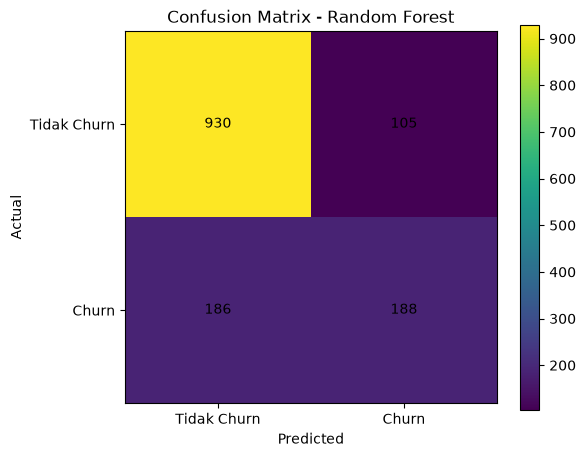

In [10]:
plt.figure(figsize=(6, 5))

plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()

plt.xticks([0, 1], ["Tidak Churn", "Churn"])
plt.yticks([0, 1], ["Tidak Churn", "Churn"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

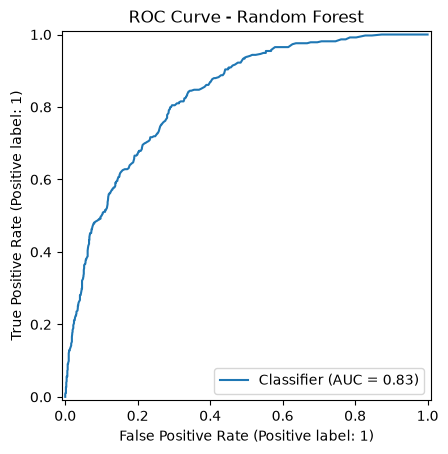

In [11]:
RocCurveDisplay.from_predictions(
    y_te,
    y_proba
)

plt.title("ROC Curve - Random Forest")
plt.show()

In [12]:
hasil_prediksi = X_te.copy()

hasil_prediksi["Actual_Churn"] = y_te.values
hasil_prediksi["Predicted_Churn"] = y_pred
hasil_prediksi["Probabilitas_Churn"] = y_proba

hasil_prediksi = hasil_prediksi.sort_values(
    "Probabilitas_Churn",
    ascending=False
)

hasil_prediksi[
    [
        "Actual_Churn",
        "Predicted_Churn",
        "Probabilitas_Churn"
    ]
].head(10)

,Actual_Churn,Predicted_Churn,Probabilitas_Churn
1731,1,1,0.963333
6623,1,1,0.956667
3727,1,1,0.950000
1739,1,1,0.943333
2927,0,1,0.943333
4039,0,1,0.930000
5098,1,1,0.926667
6866,1,1,0.923333
1696,1,1,0.923333
2631,1,1,0.916667


In [13]:
def kategori_risiko(probabilitas):
    if probabilitas >= 0.75:
        return "Tinggi"
    elif probabilitas >= 0.50:
        return "Sedang"
    else:
        return "Rendah"


hasil_prediksi["Kategori_Risiko"] = hasil_prediksi[
    "Probabilitas_Churn"
].apply(kategori_risiko)

hasil_prediksi[
    [
        "Actual_Churn",
        "Predicted_Churn",
        "Probabilitas_Churn",
        "Kategori_Risiko"
    ]
].head(10)

,Actual_Churn,Predicted_Churn,Probabilitas_Churn,Kategori_Risiko
1731,1,1,0.963333,Tinggi
6623,1,1,0.956667,Tinggi
3727,1,1,0.950000,Tinggi
1739,1,1,0.943333,Tinggi
2927,0,1,0.943333,Tinggi
4039,0,1,0.930000,Tinggi
5098,1,1,0.926667,Tinggi
6866,1,1,0.923333,Tinggi
1696,1,1,0.923333,Tinggi
2631,1,1,0.916667,Tinggi


# Kesimpulan

Pada Pertemuan 10 dilakukan klasifikasi pelanggan menggunakan algoritma Random Forest pada dataset Telco Churn. Dataset memiliki kondisi kelas yang tidak seimbang sehingga digunakan parameter `class_weight="balanced"` agar model memberikan perhatian yang lebih baik terhadap kelas minoritas, yaitu pelanggan yang mengalami churn.

Model dievaluasi menggunakan Accuracy, Precision, Recall, F1-Score, dan ROC-AUC. Recall menjadi salah satu metrik penting karena menunjukkan kemampuan model dalam menemukan pelanggan yang benar-benar mengalami churn.

Hasil `predict_proba()` juga digunakan untuk memperoleh probabilitas churn setiap pelanggan. Berdasarkan probabilitas tersebut, pelanggan dapat dikelompokkan ke dalam kategori risiko rendah, sedang, dan tinggi sehingga hasil klasifikasi dapat digunakan sebagai dasar untuk menentukan pelanggan yang perlu mendapatkan perhatian atau strategi retensi.

Secara keseluruhan, Random Forest dapat digunakan sebagai model klasifikasi untuk memprediksi churn dan membantu mengidentifikasi pelanggan yang memiliki kemungkinan tinggi untuk berhenti menggunakan layanan.